# Numerical Simulation Laboratory 
## Python Exercise 12 
## Keras - Deep & Convolutional Neural Network image recognition 

### MNIST with Keras

The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).

The MNIST dataset comprises $70000$ handwritten digits, each of which comes in a square image, divided into a $28\times 28$ pixel grid. Every pixel can take on $256$ gradation of the gray color, interpolating between white and black, and hence each data point assumes any value in the set $\{0,1,\dots,255\}$. Since there are $10$ categories in the problem, corresponding to the ten digits, this problem represents a generic **classification task**. 

In [21]:
import os
from PIL import Image
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam
from keras.layers import Flatten, Conv2D, MaxPooling2D

seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

### Pipeline

### Step 1: Load and Process the Data

Keras can conveniently download the MNIST data from the web. All we need to do is import the `mnist` module and use the `load_data()` class, and it will create the training and test data sets or us.

The MNIST set has pre-defined test and training sets, in order to facilitate the comparison of the performance of different models on the data.

Once we have loaded the data, we need to format it in the correct shape.

#### Step 2: Define the Neural Net and its Architecture

We can now move on to construct our deep neural net. We shall use Keras's `Sequential()` class to instantiate a model, and will add different deep layers one by one using the `add()` method

For the purposes of our example, it suffices to focus on `Dense` layers for simplicity. Every `Dense()` layer accepts as its first required argument an integer which specifies the number of neurons. The type of activation function for the layer is defined using the `activation` optional argument, the input of which is the name of the activation function in `string` format. Examples include `relu`, `tanh`, `elu`, `sigmoid`, `softmax`. 

In order for our DNN to work properly, we have to make sure that the numbers of input and output neurons for each layer match. Therefore, we specify the shape of the input in the first layer of the model explicitly using the optional argument `input_shape=(N_features,)`. The sequential construction of the model then allows Keras to infer the correct input/output dimensions of all hidden layers automatically. Hence, we only need to specify the size of the softmax output layer to match the number of categories.

#### Step 3: Choose the Optimizer and the Cost Function

Next, we choose the loss function according to which to train the DNN. For classification problems, this is the cross entropy, and since the output data was cast in categorical form, we choose the `categorical_crossentropy` defined in Keras' `losses` module. Depending on the problem of interest one can pick any other suitable loss function. To optimize the weights of the net, we choose SGD. This algorithm is already available to use under Keras' `optimizers` module, but we could use any other built-in one as well. The parameters for the optimizer, such as `lr` (learning rate) or `momentum` are passed using the corresponding optional arguments of the `SGD()` function. All available arguments can be found in Keras' online documentation at [https://keras.io/](https://keras.io/). While the loss function and the optimizer are essential for the training procedure, to test the performance of the model one may want to look at a particular `metric` of performance. For instance, in categorical tasks one typically looks at their `accuracy`, which is defined as the percentage of correctly classified data points. To complete the definition of our model, we use the `compile()` method, with optional arguments for the `optimizer`, `loss`, and the validation `metric`.

#### Step 4: Train the model

We train our DNN in minibatches. 

Shuffling the training data during training improves stability of the model. Thus, we train over a number of training epochs. Each epoch corresponds to using **all the train data** divided in minibatches.

Training the DNN is a one-liner using the `fit()` method of the `Sequential` class. The first two required arguments are the training input and output data. As optional arguments, we specify the mini-`batch_size`, the number of training `epochs`, and the test or `validation_data`. To monitor the training procedure for every epoch, we set `verbose=True`. 

#### Step 5: Evaluate the Model Performance on the *Unseen* Test Data

Next, we evaluate the model and read of the loss on the test data, and its accuracy using the `evaluate()` method.

Dropout, during training, slices off some artificial neurons, thus, training accuracy suffers.

Dropout, during testing, turns itself off and allows all of the ‘weak classifiers’ in the neural network to be used. Thus, testing accuracy improves with respect to training accuracy.

### Exercise 12.1

Change at will and train your DNN by increasing the number of epochs to an adeuqate value. Try to use at least two other optimizers, different from SGD: watch to accuracy and loss for training and validation data and comment on the performances.


Training model with SGD
Epoch 1/50


/opt/anaconda3/envs/dl2026/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7826 - loss: 0.7382 - val_accuracy: 0.9146 - val_loss: 0.3134
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8922 - loss: 0.3816 - val_accuracy: 0.9288 - val_loss: 0.2422
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9118 - loss: 0.3098 - val_accuracy: 0.9385 - val_loss: 0.2049
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9231 - loss: 0.2699 - val_accuracy: 0.9467 - val_loss: 0.1790
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9332 - loss: 0.2384 - val_accuracy: 0.9512 - val_loss: 0.1622
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 999us/step - accuracy: 0.9394 - loss: 0.2139 - val_accuracy: 0.9547 - val_loss: 0.1463
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9450 - loss: 0.1929 - val_accuracy: 0.9587 - val_loss: 0.1332
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9483 - loss: 0.1816 - val_accur

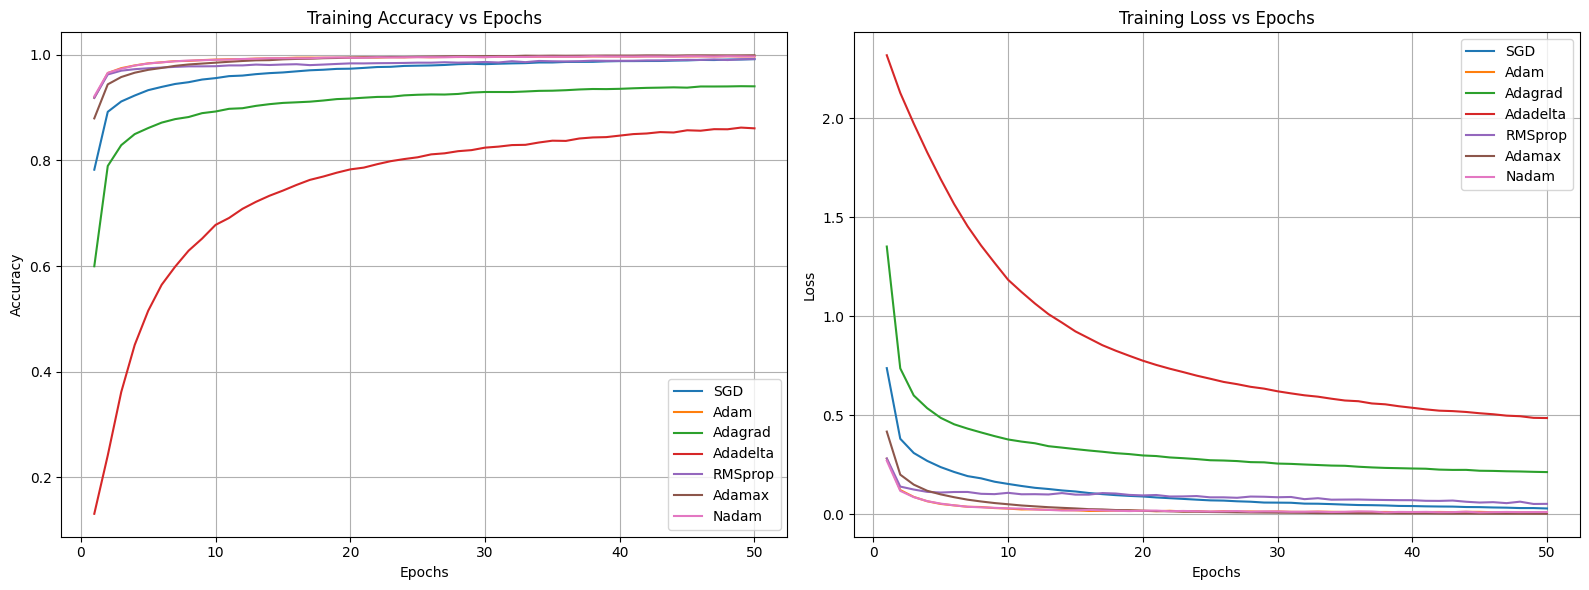

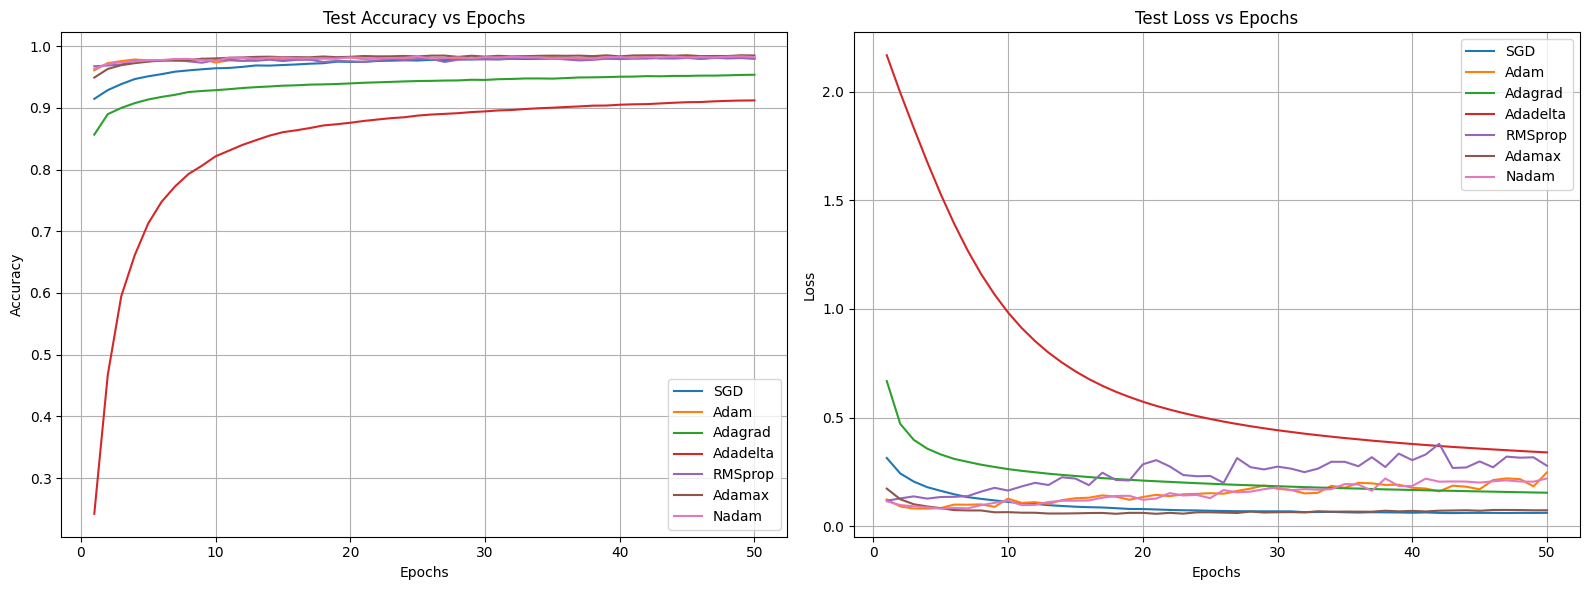


===== Final test scores =====
SGD        -> Test loss: 0.0609, Test accuracy: 0.9808
Adam       -> Test loss: 0.2473, Test accuracy: 0.9810
Adagrad    -> Test loss: 0.1535, Test accuracy: 0.9537
Adadelta   -> Test loss: 0.3393, Test accuracy: 0.9121
RMSprop    -> Test loss: 0.2775, Test accuracy: 0.9794
Adamax     -> Test loss: 0.0726, Test accuracy: 0.9849
Nadam      -> Test loss: 0.2192, Test accuracy: 0.9823


In [22]:
# =========================
# Impostazioni iniziali
# =========================
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

img_rows, img_cols = 28, 28
input_dim = img_rows * img_cols
num_classes = 10

batch_size = 32
epochs = 50

# =========================
# Caricamento e preprocessing dati
# =========================

# conservo le immagini originali per eventuali visualizzazioni
# X_test_img e X_train_img sono in formato (num_samples, 28, 28)
# X_test e X_train sono in formato (num_samples, 784) e normalizzate tra 0 e 1

(X_train_img, y_train), (X_test_img, y_test) = mnist.load_data()

X_train = X_train_img.reshape(-1, input_dim).astype("float32") / 255.0
X_test = X_test_img.reshape(-1, input_dim).astype("float32") / 255.0

Y_train = keras.utils.to_categorical(y_train, num_classes)
Y_test = keras.utils.to_categorical(y_test, num_classes)

# =========================
# Definizione del modello
# =========================
def create_dnn():
    model = Sequential([
        Dense(400, activation='relu', input_shape=(input_dim,)),
        Dense(100, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# =========================
# Dizionario ottimizzatori
# =========================
optimizers = {
    'SGD': SGD(),
    'Adam': Adam(),
    'Adagrad': Adagrad(),
    'Adadelta': Adadelta(),
    'RMSprop': RMSprop(),
    'Adamax': Adamax(),
    'Nadam': Nadam()
}

# =========================
# Compilazione e training
# =========================
models = {}
histories = {}
test_scores = {}

for name, opt in optimizers.items():
    print(f"\n==============================")
    print(f"Training model with {name}")
    print(f"==============================")
    
    model = create_dnn()
    model.compile(
        loss='categorical_crossentropy',
        optimizer=opt,
        metrics=['accuracy']
    )
    
    history = model.fit(
        X_train, Y_train,
        batch_size=batch_size,
        epochs=epochs,
        shuffle=True,
        verbose=1,
        validation_data=(X_test, Y_test)
    )
    
    score = model.evaluate(X_test, Y_test, verbose=0)
    
    models[name] = model
    histories[name] = history
    test_scores[name] = {
        'loss': score[0],
        'accuracy': score[1]
    }

# =========================
# Funzione per i grafici
# =========================
def plot_histories(histories, epochs, mode='train'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    epoch_range = range(1, epochs + 1)

    for name, hist in histories.items():
        history_dict = hist.history
        
        acc_key = 'accuracy' if 'accuracy' in history_dict else 'acc'
        val_acc_key = 'val_accuracy' if 'val_accuracy' in history_dict else 'val_acc'
        
        if mode == 'train':
            axes[0].plot(epoch_range, history_dict[acc_key], label=name)
            axes[1].plot(epoch_range, history_dict['loss'], label=name)
            axes[0].set_title('Training Accuracy vs Epochs')
            axes[1].set_title('Training Loss vs Epochs')
        elif mode == 'test':
            axes[0].plot(epoch_range, history_dict[val_acc_key], label=name)
            axes[1].plot(epoch_range, history_dict['val_loss'], label=name)
            axes[0].set_title('Test Accuracy vs Epochs')
            axes[1].set_title('Test Loss vs Epochs')

    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# =========================
# Grafici
# =========================
plot_histories(histories, epochs, mode='train')
plot_histories(histories, epochs, mode='test')

# =========================
# Risultati finali
# =========================
print("\n===== Final test scores =====")
for name, score in test_scores.items():
    print(f"{name:10s} -> Test loss: {score['loss']:.4f}, Test accuracy: {score['accuracy']:.4f}")

In [23]:
# estrazione modello con accuracy massima su test set
best_model_name = max(test_scores, key=lambda name: test_scores[name]['accuracy'])
best_model = models[best_model_name]

print(f"Best Optimizer: {best_model_name}")
print(f"Test Accuracy: {test_scores[best_model_name]['accuracy']:.4f}")
print(f"Test Loss: {test_scores[best_model_name]['loss']:.4f}")

Best Optimizer: Adamax
Test Accuracy: 0.9849
Test Loss: 0.0726


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step


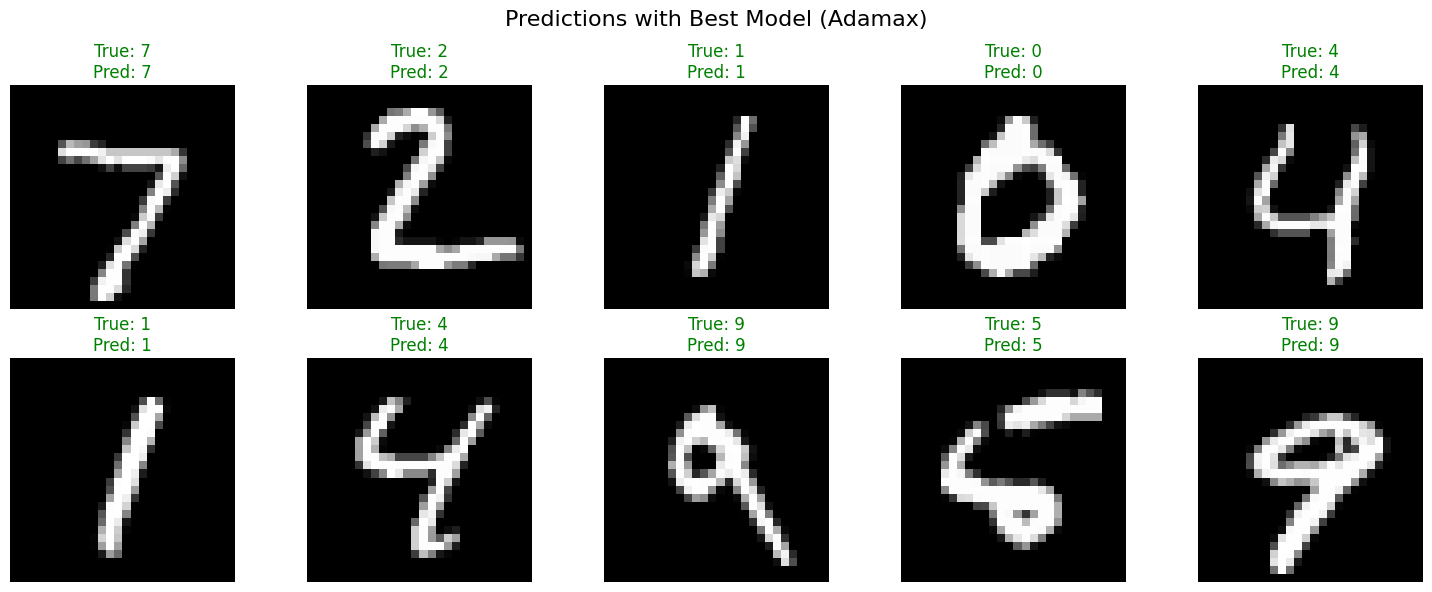

In [24]:
# predizioni con il modello migliore
predictions = best_model.predict(X_test)

# visualizzazione di prime 10 immagini
plt.figure(figsize=(15, 6))

for i in range(10):
    true_label = np.argmax(Y_test[i])
    pred_label = np.argmax(predictions[i])
    color = 'green' if true_label == pred_label else 'red'
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_img[i], cmap='gray')
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.suptitle(f"Predictions with Best Model ({best_model_name})", fontsize=16)
plt.tight_layout()
plt.show()

___
### Exercise 12.2

Change the architecture of your DNN using convolutional layers. Use `Conv2D`, `MaxPooling2D`, `Dropout`, but also do not forget `Flatten`, a standard `Dense` layer and `soft-max` in the end. I have merged step 2 and 3 in the following definition of `create_CNN()` that you should complete:

Per il problema di classificazione delle cifre MNIST è stata scelta una Convolutional Neural Network, in quanto le immagini presentano correlazioni spaziali locali tra pixel vicini e una moderata invarianza rispetto a piccole traslazioni.
L’architettura adottata è composta da due layer convoluzionali con attivazione ReLU, rispettivamente con 32 e 64 filtri di dimensione 3×3, ciascuno seguito da un layer di max pooling 2×2.
Dopo l’estrazione delle feature, le mappe ottenute vengono appiattite tramite un layer Flatten e passate a un layer fully-connected di 128 neuroni, seguito da dropout per regolarizzazione.
L’output finale è costituito da 10 neuroni con attivazione softmax, adatti alla classificazione multiclasse.

In [25]:
# =========================
# Impostazioni iniziali
# =========================
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

img_rows, img_cols = 28, 28
num_classes = 10
batch_size = 32
epochs = 30

# =========================
# Caricamento dati
# =========================
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# conversione a float e normalizzazione
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# reshape per CNN
if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

# one-hot encoding
Y_train = keras.utils.to_categorical(y_train, num_classes)
Y_test = keras.utils.to_categorical(y_test, num_classes)

# =========================
# Definizione CNN
# =========================
def create_cnn():
    model = Sequential([
        Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        
        Conv2D(64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        
        Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# =========================
# Compilazione
# =========================
model_CNN = create_cnn()

model_CNN.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

# =========================
# Training
# =========================
history_CNN = model_CNN.fit(
    X_train, Y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    shuffle=True,
    validation_data=(X_test, Y_test)
)

# =========================
# Valutazione finale
# =========================
score = model_CNN.evaluate(X_test, Y_test, verbose=0)

print(f"Test loss: {score[0]:.4f}")
print(f"Test accuracy: {score[1]:.4f}")

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9348 - loss: 0.2142 - val_accuracy: 0.9836 - val_loss: 0.0467
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9753 - loss: 0.0839 - val_accuracy: 0.9881 - val_loss: 0.0342
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9813 - loss: 0.0645 - val_accuracy: 0.9901 - val_loss: 0.0264
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9836 - loss: 0.0554 - val_accuracy: 0.9910 - val_loss: 0.0267
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9857 - loss: 0.0457 - val_accuracy: 0.9916 - val_loss: 0.0251
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9874 - loss: 0.0418 - val_accuracy: 0.9917 - val_loss: 0.0245
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9879 - loss: 0.0396 - val_accuracy: 0.9921 - val_loss: 0.0237
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9881 - loss: 0

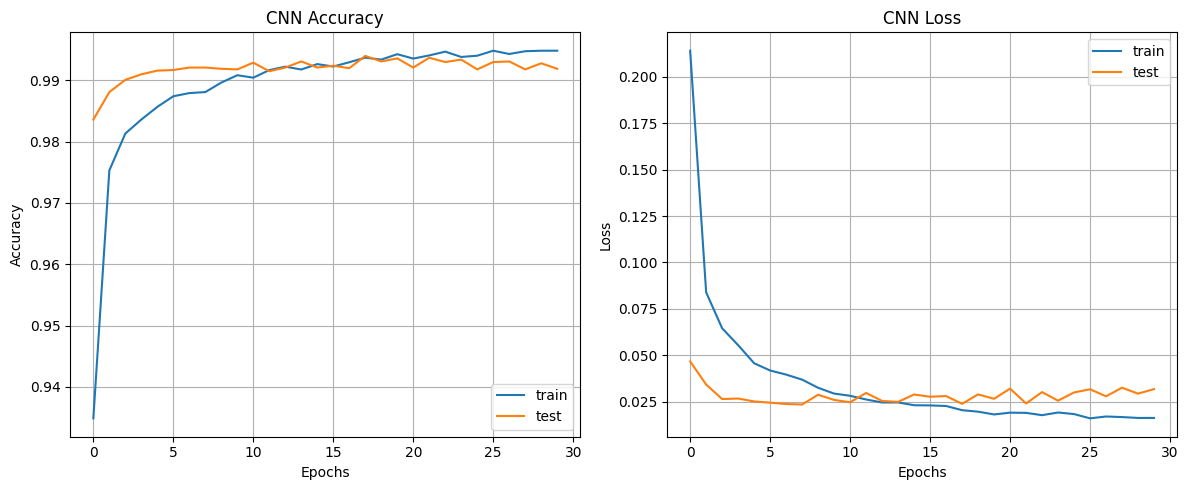

In [26]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_CNN.history['accuracy'], label='train')
plt.plot(history_CNN.history['val_accuracy'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_CNN.history['loss'], label='train')
plt.plot(history_CNN.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


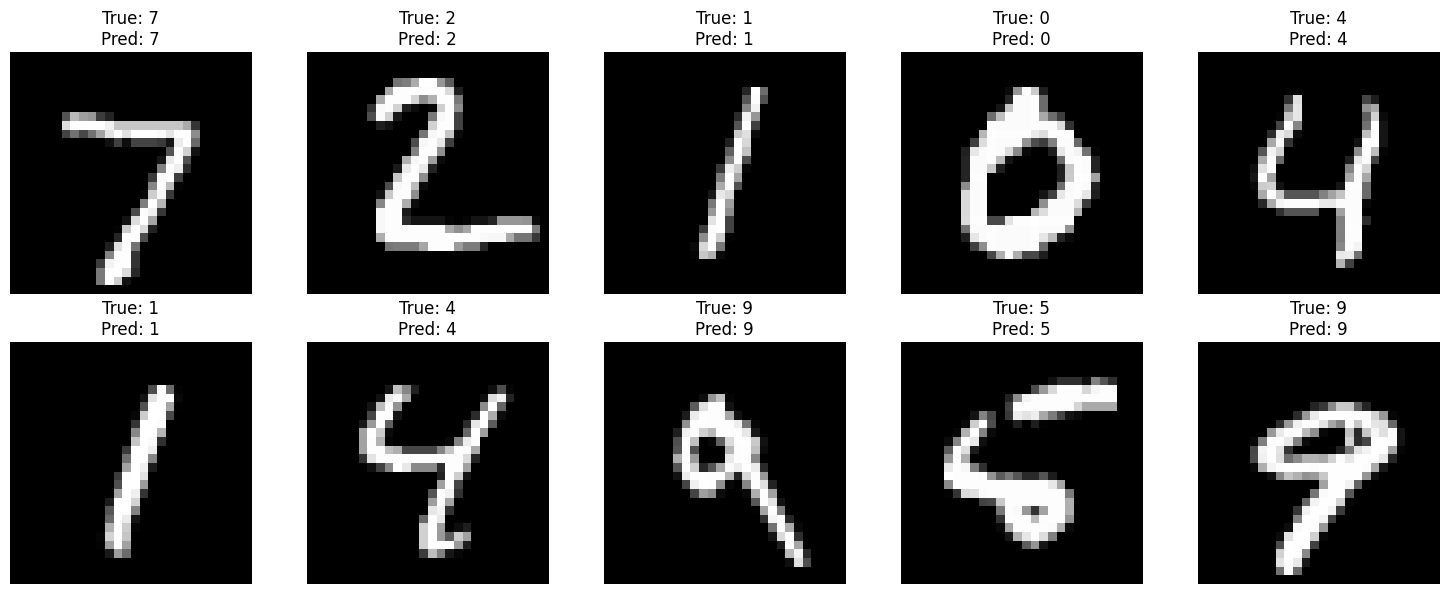

In [27]:
predictions = model_CNN.predict(X_test)

plt.figure(figsize=(15,6))
for i in range(10):
    true_label = np.argmax(Y_test[i])
    pred_label = np.argmax(predictions[i])
    color = 'green' if true_label == pred_label else 'red'

    plt.subplot(2,5,i+1)
    if keras.backend.image_data_format() == 'channels_first':
        plt.imshow(X_test[i, 0, :, :], cmap='gray')
    else:
        plt.imshow(X_test[i, :, :, 0], cmap='gray')

    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

___
### Exercise 12.3

Use the `gimp` application to create 10 pictures of your "handwritten" digits, import them in your jupyter-notebook and try to see if your CNN is able to recognize your handwritten digits.

For example, you can use the following code to import a picture of an handwritten digit
(Note: you should install Python Image Library (PIL/Pillow)).

In [28]:
# =========================
# Parametri
# =========================
img_rows, img_cols = 28, 28
digits_path = "digits"

# =========================
# Caricamento immagini
# =========================
images = []
true_labels = []

for digit in range(1, 10):
    filename = os.path.join(digits_path, f"digit_{digit}.png")
    
    # apertura immagine in grayscale
    img = Image.open(filename).convert("L")
    
    # sicurezza: resize a 28x28 nel caso non fosse perfetta
    img = img.resize((img_cols, img_rows))
    
    # conversione in array numpy
    img_array = np.array(img).astype("float32")
    
    images.append(img_array)
    true_labels.append(digit)

images = np.array(images)                  # shape: (9, 28, 28)
true_labels = np.array(true_labels)

# =========================
# Normalizzazione
# =========================
images_norm = images / 255.0

# =========================
# Input per DNN
# =========================
X_digits_dnn = images_norm.reshape(images_norm.shape[0], img_rows * img_cols)

# =========================
# Input per CNN
# =========================
if keras.backend.image_data_format() == 'channels_first':
    X_digits_cnn = images_norm.reshape(images_norm.shape[0], 1, img_rows, img_cols)
else:
    X_digits_cnn = images_norm.reshape(images_norm.shape[0], img_rows, img_cols, 1)

# =========================
# Predizioni
# =========================
pred_dnn = best_model.predict(X_digits_dnn)
pred_cnn = model_CNN.predict(X_digits_cnn)

pred_labels_dnn = np.argmax(pred_dnn, axis=1)
pred_labels_cnn = np.argmax(pred_cnn, axis=1)

# =========================
# Stampa risultati numerici
# =========================
print("Handwritten classification results:\n")
for i in range(len(true_labels)):
    print(f"Immagine digit_{true_labels[i]}.png -> "
          f"DNN ({best_model_name}): {pred_labels_dnn[i]} | "
          f"CNN: {pred_labels_cnn[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Handwritten classification results:

Immagine digit_1.png -> DNN (Adamax): 1 | CNN: 1
Immagine digit_2.png -> DNN (Adamax): 2 | CNN: 2
Immagine digit_3.png -> DNN (Adamax): 3 | CNN: 3
Immagine digit_4.png -> DNN (Adamax): 6 | CNN: 4
Immagine digit_5.png -> DNN (Adamax): 6 | CNN: 5
Immagine digit_6.png -> DNN (Adamax): 6 | CNN: 6
Immagine digit_7.png -> DNN (Adamax): 3 | CNN: 3
Immagine digit_8.png -> DNN (Adamax): 3 | CNN: 8
Immagine digit_9.png -> DNN (Adamax): 6 | CNN: 3
